# Vietnamese Food VQA — Eval & Visualize

1. Setup + load predictions
2. Metric functions (EM, BLEU, ROUGE-L, BERTScore)
3. **Bảng + biểu đồ** so sánh các cấu hình
4. Xem sample test trực quan (ảnh + câu hỏi + gold + 4 prediction)
5. Tìm sample theo món / từ khoá
6. So sánh A1 vs A2
7. So sánh B1 vs B2
8. Per-question-type + Per-món
9. B2 vs B2-DPO

## 0. Setup

In [1]:
# (Colab) — uncomment 3 dòng dưới nếu đang chạy Colab
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/final_Deep

Mounted at /content/drive
/content/drive/MyDrive/final_Deep


In [2]:
! pip install -q -U google-genai sacrebleu rouge_score bert_score torchao bitsandbytes accelerate transformers


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 685.9 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.7/793.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.5/246.5 kB 16.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.50.0 which is incompatible.


In [3]:
import json, random, re, string, time, unicodedata, os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
from tqdm.auto import tqdm

import config

OUT = config.OUT_DIR
ROOT = config.ROOT
CONFIGS = ['A1', 'A2', 'B1', 'B2', 'B2_DPO']
COLORS = {'A1': '#1f77b4', 'A2': '#ff7f0e', 'B1': '#2ca02c', 'B2': '#d62728', 'B2_DPO': '#9467bd'}

def load_preds(cfg):
    p = OUT / f'{cfg}_test.json'
    if not p.exists():
        return None
    return json.loads(p.read_text(encoding='utf-8'))

preds = {cfg: load_preds(cfg) for cfg in CONFIGS}
preds = {k: v for k, v in preds.items() if v is not None}

print('Predictions có sẵn:')
for k, v in preds.items():
    print(f'  {k}: {len(v)} samples')
if not preds:
    print('Chưa có file predictions nào — chạy `python infer.py --mode a1` trước.')

Predictions có sẵn:
  A1: 3793 samples
  A2: 3793 samples
  B1: 3747 samples
  B2: 3793 samples
  B2_DPO: 3793 samples


## 1. Metric functions

In [4]:
_PUNCT_RE = re.compile(f'[{re.escape(string.punctuation)}]')

def normalize_text(t: str) -> str:
    t = unicodedata.normalize('NFC', t).lower().strip()
    t = _PUNCT_RE.sub(' ', t)
    return ' '.join(t.split())

def metric_em(preds, golds):
    return sum(normalize_text(p) == normalize_text(g) for p, g in zip(preds, golds)) / len(preds)

def metric_bleu(preds, golds):
    import sacrebleu
    return sacrebleu.corpus_bleu(preds, [golds]).score / 100.0

def metric_rouge_l(preds, golds):
    from rouge_score import rouge_scorer
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
    s = sum(scorer.score(g, p)['rougeL'].fmeasure for p, g in zip(preds, golds))
    return s / len(preds)

def metric_bertscore(preds, golds, model_type='xlm-roberta-base'):
    from bert_score import score
    P, R, F = score(preds, golds, model_type=model_type, lang='vi', verbose=False)
    return F.mean().item()

print('Metric functions ready.')

Metric functions ready.


## 2. Tính metrics tự động cho mọi cấu hình

In [5]:
results = {}
for cfg, rows in preds.items():
    p_list = [r['pred'] for r in rows]
    g_list = [r['gold'] for r in rows]
    print(f'Computing {cfg} ({len(rows)} samples) ...')
    results[cfg] = {
        'EM':       metric_em(p_list, g_list),
        'BLEU':     metric_bleu(p_list, g_list),
        'ROUGE-L':  metric_rouge_l(p_list, g_list),
        'BERTScore':metric_bertscore(p_list, g_list),
    }

df = pd.DataFrame(results).T
df.index.name = 'config'
df = df.round(4)
display(df.style.background_gradient(cmap='Greens', axis=0).format('{:.4f}'))

Computing A1 (3793 samples) ...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing B2_DPO (3793 samples) ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,EM,BLEU,ROUGE-L,BERTScore
config,,,,
A1,0.4474,0.6321,0.8447,0.9571
A2,0.4405,0.6383,0.8477,0.9573
B1,0.0069,0.0725,0.3643,0.8548
B2,0.3926,0.4691,0.7510,0.9514
B2_DPO,0.4358,0.5898,0.8125,0.9693


## 3. Biểu đồ cột — so sánh 4 metric

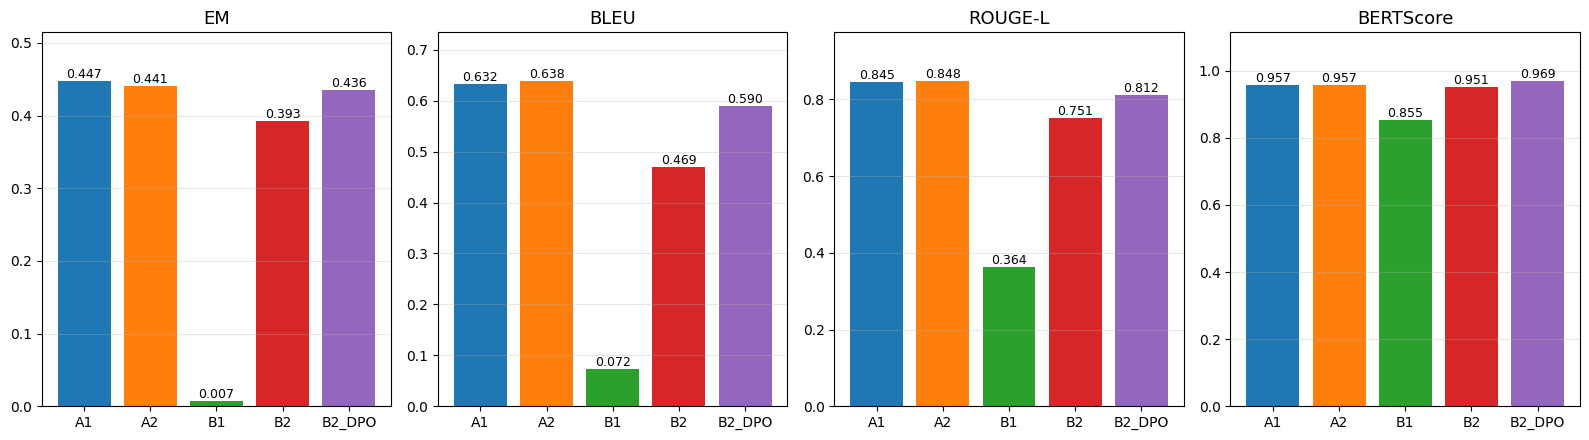

In [6]:
metric_cols = ['EM', 'BLEU', 'ROUGE-L', 'BERTScore']
fig, axes = plt.subplots(1, len(metric_cols), figsize=(4 * len(metric_cols), 4.5))
if len(metric_cols) == 1:
    axes = [axes]
for ax, m in zip(axes, metric_cols):
    cfgs = list(df.index)
    vals = [df.loc[c, m] for c in cfgs]
    bars = ax.bar(cfgs, vals, color=[COLORS.get(c, '#888') for c in cfgs])
    ax.set_title(m, fontsize=13)
    ax.set_ylim(0, max(max(vals) * 1.15, 0.05))
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height(),
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Xem N sample test ngẫu nhiên

Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/tom_kho/000053.jpg
Image exists: True


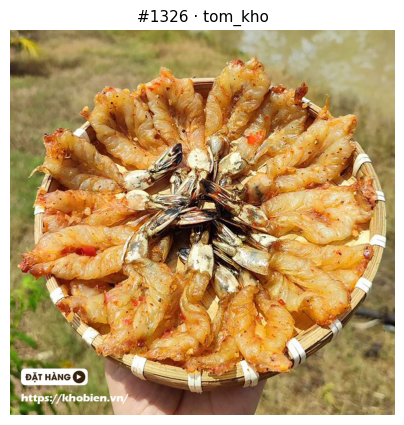

  Q   : Góc chụp của bức ảnh là gì?
  Gold: Ảnh có góc chụp từ trên xuống.
  [✓] A1    : Ảnh có góc chụp từ trên xuống .
  [✓] A2    : Ảnh có góc chụp từ trên xuống .
  [ ] B1    : Có
  [✓] B2    : Ảnh có góc chụp từ trên xuống.
  [✓] B2_DPO: Ảnh có góc chụp từ trên xuống.
--------------------------------------------------------------------------------
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/cha_que_Hung_Yen/000044.jpg
Image exists: True


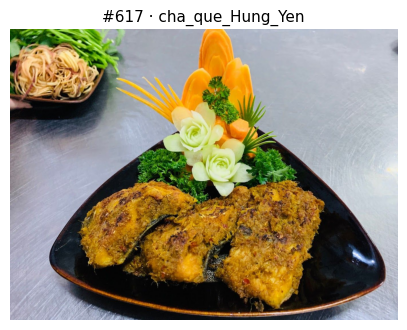

  Q   : Góc chụp của bức ảnh là gì?
  Gold: Ảnh có Góc chụp từ trên xuống.
  [✓] A1    : Ảnh có góc chụp từ trên xuống .
  [✓] A2    : Ảnh có góc chụp từ trên xuống .
  [ ] B1    : Cú pháp
  [✓] B2    : Ảnh có góc chụp từ trên xuống.
  [✓] B2_DPO: Ảnh có góc chụp từ trên xuống.
--------------------------------------------------------------------------------
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/bun_bo_Hue/000009.jpg
Image exists: True


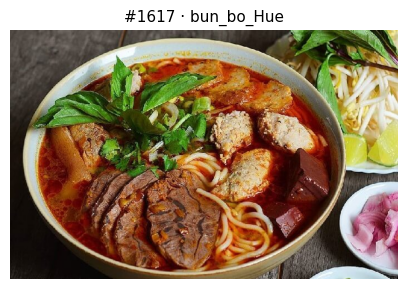

  Q   : Trong ảnh có những màu nào?
  Gold: Trong ảnh có các màu đỏ, nâu và trắng.
  [ ] A1    : Trong ảnh có các màu đỏ , trắng và nâu
  [ ] A2    : Trong ảnh có các màu đỏ , trắng và nâu
  [ ] B1    : Xanh, đỏ, vàng
  [ ] B2    : Trong ảnh có các màu xanh và vàng.
  [ ] B2_DPO: Trong ảnh có các màu đỏ, vàng và xanh.
--------------------------------------------------------------------------------
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/mut_Tet/000038.jpg
Image exists: True


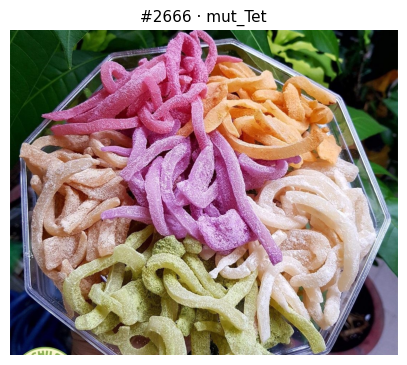

  Q   : Bức ảnh được chụp theo góc nào?
  Gold: Ảnh có góc chụp từ trên xuống.
  [✓] A1    : Ảnh có góc chụp từ trên xuống .
  [✓] A2    : Ảnh có góc chụp từ trên xuống .
  [ ] B1    : Tất cả ảnh đều có màu xanh.
  [✓] B2    : Ảnh có góc chụp từ trên xuống.
  [✓] B2_DPO: Ảnh có góc chụp từ trên xuống.
--------------------------------------------------------------------------------
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/banh_xeo/000024.jpg
Image exists: True


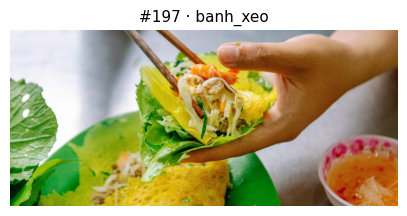

  Q   : Các nguyên vật liệu trong ảnh là gì?
  Gold: Món này có bột gạo của bánh xèo, gỗ.
  [ ] A1    : Món này có bột gạo của bánh xèo và gỗ
  [✓] A2    : Món này có bột gạo của bánh xèo , gỗ
  [ ] B1    : Trái
  [ ] B2    : Món này có gỗ của bàn và nhựa của ghế.
  [ ] B2_DPO: Món này có bột gạo của bánh xèo, tre.
--------------------------------------------------------------------------------


In [11]:
def show_sample(idx, preds_dict):
    any_cfg = next(iter(preds_dict))
    row = preds_dict[any_cfg][idx]

    original_relative_path = Path(row['image_path'])
    normalized_relative_path = original_relative_path
    if original_relative_path.parts and original_relative_path.parts[0] == 'data':
        normalized_relative_path = original_relative_path.relative_to('data')

    possible_base_paths = [
        ROOT,
        config.IMAGES_ROOT,
        Path('/content'),
        Path('.')
    ]

    found_img_path = None
    for base_path in possible_base_paths:
        candidate_path_orig = base_path / original_relative_path
        if candidate_path_orig.exists():
            found_img_path = candidate_path_orig
            break

        candidate_path_norm = base_path / normalized_relative_path
        if candidate_path_norm.exists():
            found_img_path = candidate_path_norm
            break

    print(f'Attempting to load image from: {found_img_path if found_img_path else "Multiple candidates checked"}')
    print(f'Image exists: {found_img_path is not None and found_img_path.exists()}')

    fig, ax = plt.subplots(figsize=(5, 5))
    if found_img_path and found_img_path.exists():
        ax.imshow(Image.open(found_img_path).convert('RGB'))
    else:
        ax.text(0.5, 0.5, 'Image not found', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=12, color='red')

    ax.axis('off')
    dish = 'unknown'
    if found_img_path:
        dish = found_img_path.parent.name
    elif normalized_relative_path.parts and len(normalized_relative_path.parts) >= 2:
        dish = normalized_relative_path.parts[-2]

    ax.set_title(f'#{idx} · {dish}', fontsize=11)
    plt.show()
    print(f'  Q   : {row["question"]}')
    print(f'  Gold: {row["gold"]}')
    for cfg in CONFIGS:
        if cfg in preds_dict:
            pred = preds_dict[cfg][idx]['pred']
            mark = '✓' if normalize_text(pred) == normalize_text(row['gold']) else ' '
            print(f'  [{mark}] {cfg:6s}: {pred}')

N_SAMPLES = 5
if preds:
    n_total = len(next(iter(preds.values())))
    random.seed(7)
    for idx in random.sample(range(n_total), N_SAMPLES):
        show_sample(idx, preds)
        print('-' * 80)

## 6. So sánh A1 vs A2

A1 đúng / A2 sai: 171
A2 đúng / A1 sai: 145

=== Ví dụ A1 thắng ===
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/cha_lua/000006.jpg
Image exists: True


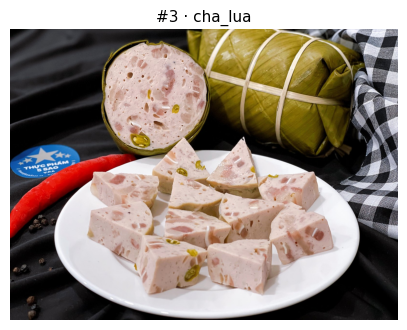

  Q   : Món ăn có những nguyên vật liệu nào?
  Gold: Món này có thịt của Chả lụa, lá chuối.
  [✓] A1    : Món này có thịt của Chả lụa , lá chuối
  [ ] A2    : Món này có thịt xay , lá chuối và gốm
--------------------------------------------------------------------------------
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/cha_lua/000006.jpg
Image exists: True


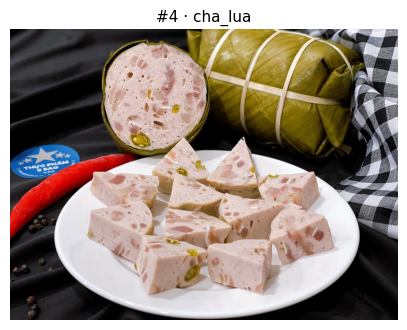

  Q   : Các nguyên vật liệu trong ảnh là gì?
  Gold: Món này có thịt của Chả lụa, lá chuối.
  [✓] A1    : Món này có thịt của Chả lụa , lá chuối
  [ ] A2    : Món này có thịt , lá chuối và sứ .
--------------------------------------------------------------------------------
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/banh_pia/000058.jpg
Image exists: True


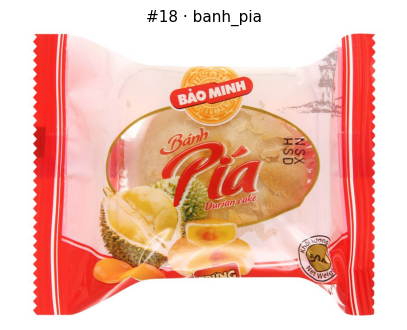

  Q   : Trong ảnh có những màu nào?
  Gold: Trong ảnh có các màu đỏ, vàng và trắng.
  [✓] A1    : Trong ảnh có các màu đỏ , vàng và trắng
  [ ] A2    : Trong ảnh có các màu vàng , đỏ và trắng
--------------------------------------------------------------------------------

=== Ví dụ A2 thắng ===
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/tom_kho/000010.png
Image exists: True


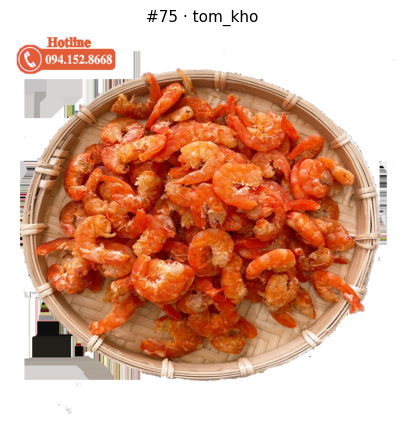

  Q   : Bạn có thấy mẹt tre trong ảnh không?
  Gold: Trong ảnh có mẹt tre.
  [ ] A1    : Trong ảnh có xiên tre .
  [✓] A2    : Trong ảnh có mẹt tre .
--------------------------------------------------------------------------------
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/vit_quay/000043.jpg
Image exists: True


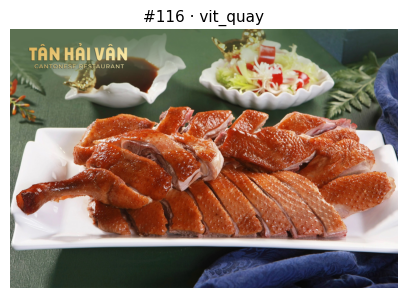

  Q   : Bạn thấy món gì trong ảnh?
  Gold: Trong ảnh là Vịt quay.
  [ ] A1    : Trong ảnh là Nem nướng .
  [✓] A2    : Trong ảnh là Vịt quay .
--------------------------------------------------------------------------------
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/vit_quay/000043.jpg
Image exists: True


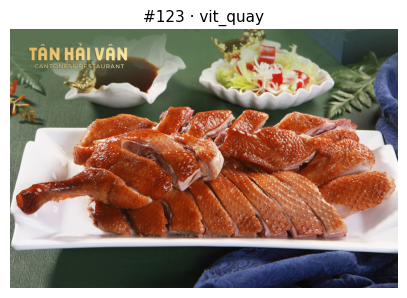

  Q   : Bức ảnh được chụp theo góc nào?
  Gold: Ảnh có Góc chụp từ trên xuống.
  [ ] A1    : Ảnh có góc chụp nghiêng .
  [✓] A2    : Ảnh có góc chụp từ trên xuống .
--------------------------------------------------------------------------------


In [12]:
def diff_cases(cfg_a, cfg_b, max_show=3):
    if cfg_a not in preds or cfg_b not in preds:
        print(f'Cần cả {cfg_a} và {cfg_b}.'); return
    ra, rb = preds[cfg_a], preds[cfg_b]
    a_win, b_win = [], []
    for i, (xa, xb) in enumerate(zip(ra, rb)):
        gold = normalize_text(xa['gold'])
        pa, pb = normalize_text(xa['pred']), normalize_text(xb['pred'])
        if pa == gold and pb != gold: a_win.append(i)
        elif pa != gold and pb == gold: b_win.append(i)
    print(f'{cfg_a} đúng / {cfg_b} sai: {len(a_win)}')
    print(f'{cfg_b} đúng / {cfg_a} sai: {len(b_win)}')
    print(f'\n=== Ví dụ {cfg_a} thắng ===')
    for idx in a_win[:max_show]:
        show_sample(idx, {cfg_a: preds[cfg_a], cfg_b: preds[cfg_b]})
        print('-' * 80)
    print(f'\n=== Ví dụ {cfg_b} thắng ===')
    for idx in b_win[:max_show]:
        show_sample(idx, {cfg_a: preds[cfg_a], cfg_b: preds[cfg_b]})
        print('-' * 80)

diff_cases('A1', 'A2', max_show=3)

## 7. So sánh B1 vs B2 (zero-shot vs fine-tune)

B1 đúng / B2 sai: 20
B2 đúng / B1 sai: 357

=== Ví dụ B1 thắng ===
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/chao_long/000003.jpg
Image exists: True


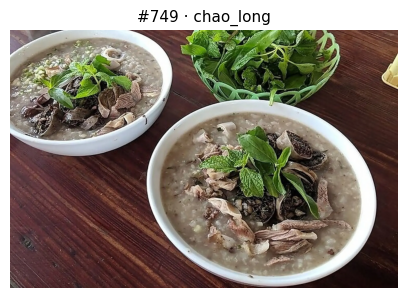

  Q   : Trong ảnh có màu trắng không?
  Gold: Trong ảnh có màu trắng.
  [✓] B1    : Trong ảnh có màu trắng.
  [ ] B2    : Trong ảnh có bánh bao.
--------------------------------------------------------------------------------
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/com_tam_Sai_Gon/000046.jpg
Image exists: True


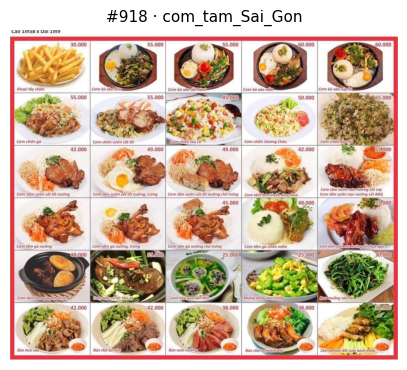

  Q   : Trong ảnh có màu trắng không?
  Gold: Trong ảnh có màu trắng.
  [✓] B1    : Trong ảnh có màu trắng.
  [ ] B2    : Trong ảnh có bao bì nhựa.
--------------------------------------------------------------------------------
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/bun_thit_nuong/000035.png
Image exists: True


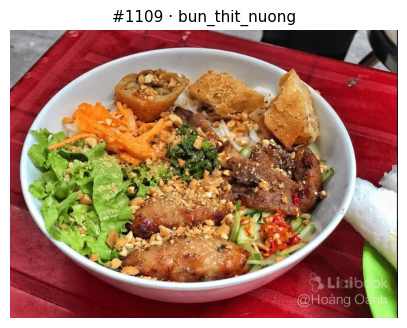

  Q   : Trong ảnh có màu trắng không?
  Gold: Trong ảnh có màu trắng.
  [✓] B1    : Trong ảnh có màu trắng.
  [ ] B2    : Trong ảnh có lá dong.
--------------------------------------------------------------------------------

=== Ví dụ B2 thắng ===
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/cha_lua/000006.jpg
Image exists: True


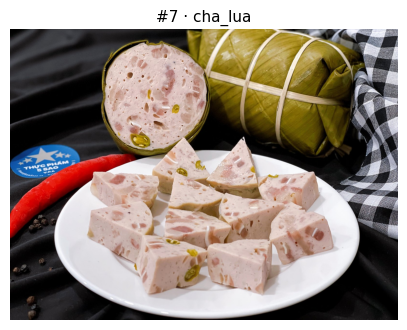

  Q   : Bức ảnh được chụp theo góc nào?
  Gold: Ảnh có góc chụp từ trên xuống.
  [ ] B1    : Cận
  [✓] B2    : Ảnh có góc chụp từ trên xuống.
--------------------------------------------------------------------------------
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/cha_lua/000006.jpg
Image exists: True


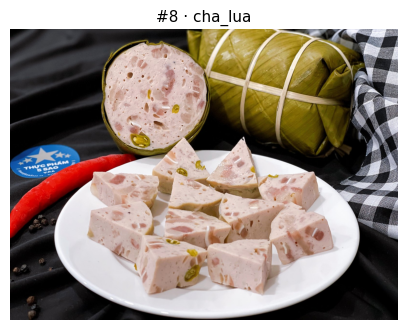

  Q   : Góc chụp của bức ảnh là gì?
  Gold: Ảnh có góc chụp từ trên xuống.
  [ ] B1    : Góc chụp của bức ảnh là một món ăn.
  [✓] B2    : Ảnh có góc chụp từ trên xuống.
--------------------------------------------------------------------------------
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/cha_lua/000006.jpg
Image exists: True


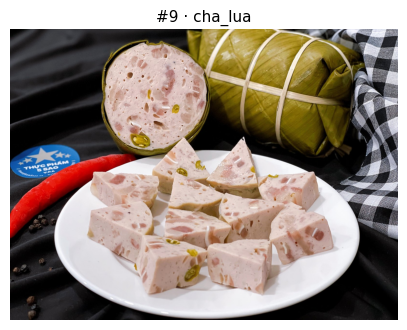

  Q   : Trong ảnh có chả lụa cắt lát không?
  Gold: Trong ảnh có Chả lụa cắt lát.
  [ ] B1    : Có
  [✓] B2    : Trong ảnh có Chả lụa cắt lát.
--------------------------------------------------------------------------------


In [13]:
diff_cases('B1', 'B2', max_show=3)

## 8. Per-question-type accuracy

=== ROUGE-L per question_type ===


config,A1,A2,B1,B2,B2_DPO
qtype,,,,,
colors_list,0.858,0.854,0.428,0.800,0.845
composition,0.854,0.851,0.354,0.862,0.860
materials_list,0.711,0.711,0.299,0.497,0.662
name_dish,0.915,0.921,0.304,0.606,0.696
objects_list,0.688,0.702,0.410,0.433,0.577
yes_no_color,0.997,0.998,0.374,1.000,1.000
yes_no_object,0.932,0.941,0.351,0.999,0.999


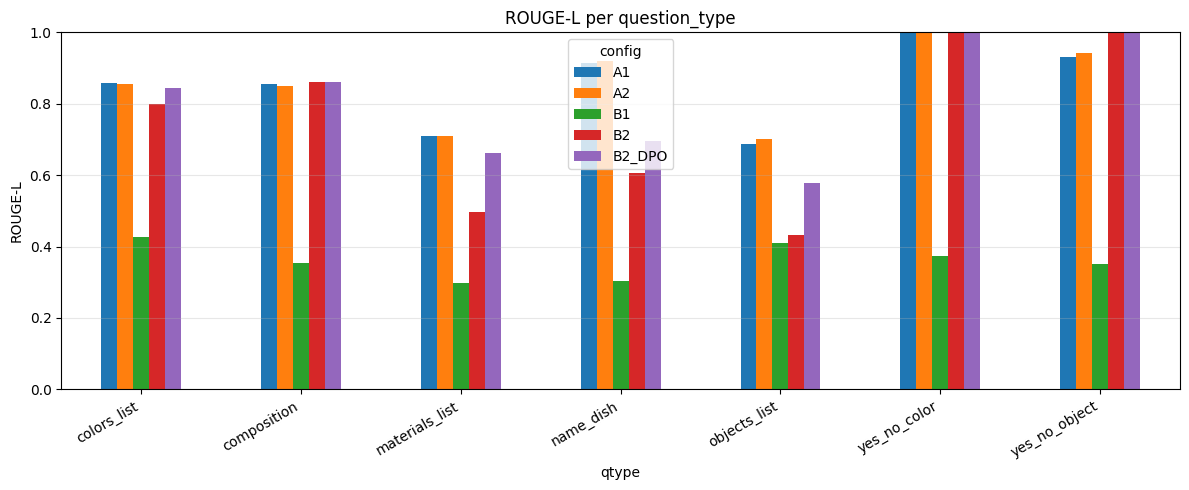

In [14]:
from rouge_score import rouge_scorer
_rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)

test_meta_path = config.SPLITS_DIR / 'test_pairs.json'
if test_meta_path.exists():
    test_meta = json.loads(test_meta_path.read_text(encoding='utf-8'))
    qtype_by_key = {(r['image_path'], r['question']): r.get('question_type', 'unknown')
                    for r in test_meta}

    rows_qt = []
    for cfg, items in preds.items():
        for r in items:
            qt = qtype_by_key.get((r['image_path'], r['question']), 'unknown')
            rl = _rouge.score(r['gold'], r['pred'])['rougeL'].fmeasure
            rows_qt.append({'config': cfg, 'qtype': qt, 'rouge_l': rl})
    df_qt = pd.DataFrame(rows_qt)

    pivot_rl = df_qt.pivot_table(index='qtype', columns='config', values='rouge_l',
                                  aggfunc='mean').round(3)

    print('=== ROUGE-L per question_type ===')
    display(pivot_rl.style.background_gradient(cmap='Greens', axis=1).format('{:.3f}'))

    ax = pivot_rl.plot(kind='bar', figsize=(12, 5),
                       color=[COLORS.get(c, '#888') for c in pivot_rl.columns])
    ax.set_ylabel('ROUGE-L')
    ax.set_title('ROUGE-L per question_type')
    ax.set_ylim(0, 1)
    plt.xticks(rotation=30, ha='right')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f'Không tìm thấy {test_meta_path} — bỏ qua phân tích question_type.')

## 9. B2 vs B2-DPO

B2 đúng / B2_DPO sai: 11
B2_DPO đúng / B2 sai: 175

=== Ví dụ B2 thắng ===
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/keo_dua_Ben_Tre/000021.png
Image exists: True


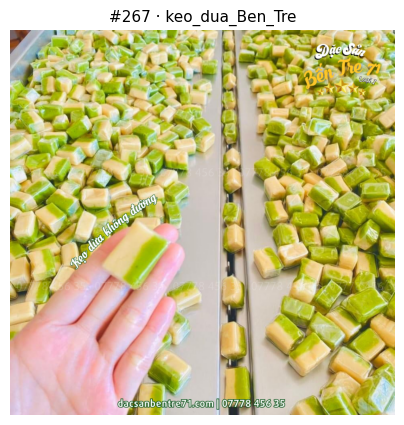

  Q   : Trong ảnh có kẹo dừa không đường không?
  Gold: Trong ảnh có kẹo dừa không đường.
  [✓] B2    : Trong ảnh có kẹo dừa không đường.
  [ ] B2_DPO: Trong ảnh có kẹo dừa không đường không.
--------------------------------------------------------------------------------
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/banh_chung_gu/000028.jpg
Image exists: True


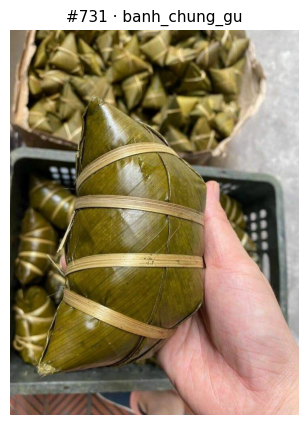

  Q   : Trong ảnh có những màu nào?
  Gold: Trong ảnh có các màu xanh và vàng.
  [✓] B2    : Trong ảnh có các màu xanh và vàng.
  [ ] B2_DPO: Trong ảnh có các màu xanh.
--------------------------------------------------------------------------------
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/cao_lau_Hoi_An/000034.jpg
Image exists: True


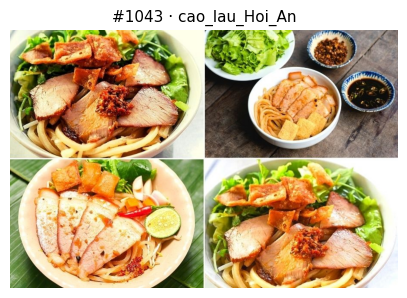

  Q   : Góc chụp của bức ảnh là gì?
  Gold: Ảnh có góc chụp từ trên xuống.
  [✓] B2    : Ảnh có góc chụp từ trên xuống.
  [ ] B2_DPO: Ảnh có 4 hình ảnh ghép.
--------------------------------------------------------------------------------

=== Ví dụ B2_DPO thắng ===
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/banh_pia/000058.jpg
Image exists: True


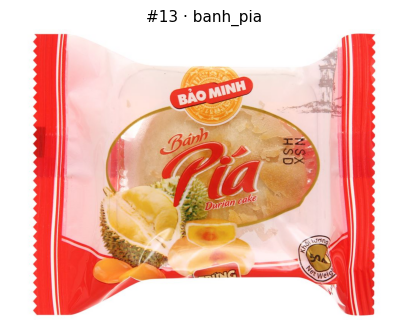

  Q   : Bạn thấy món gì trong ảnh?
  Gold: Trong ảnh là Bánh pía.
  [ ] B2    : Trong ảnh là Bún chả.
  [✓] B2_DPO: Trong ảnh là Bánh pía.
--------------------------------------------------------------------------------
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/banh_pia/000058.jpg
Image exists: True


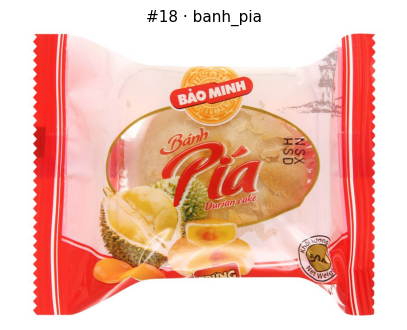

  Q   : Trong ảnh có những màu nào?
  Gold: Trong ảnh có các màu đỏ, vàng và trắng.
  [ ] B2    : Trong ảnh có các màu xanh và vàng.
  [✓] B2_DPO: Trong ảnh có các màu đỏ, vàng và trắng.
--------------------------------------------------------------------------------
Attempting to load image from: /content/drive/MyDrive/final_Deep/images/am_thuc/banh_pia/000058.jpg
Image exists: True


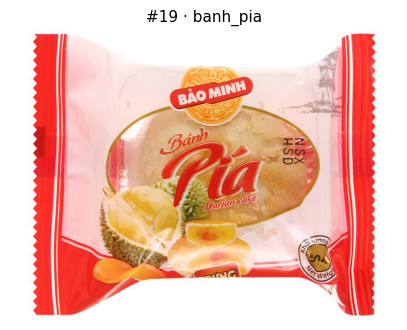

  Q   : Bạn thấy những màu gì trong ảnh?
  Gold: Trong ảnh có các màu đỏ, vàng và trắng.
  [ ] B2    : Trong ảnh có các màu xanh và trắng.
  [✓] B2_DPO: Trong ảnh có các màu đỏ, vàng và trắng.
--------------------------------------------------------------------------------


In [15]:
if 'B2_DPO' in preds and 'B2' in preds:
    diff_cases('B2', 'B2_DPO', max_show=3)
else:
    print('Chưa có B2 hoặc B2_DPO predictions.')

# DEMO


In [16]:
!pip install gradio -q

# 2. Import hàm build_app từ file demo.py (đảm bảo tên file là demo.py)
from demo import build_app

# 3. Khởi chạy với tham số share=True
app = build_app()
app.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://2042f5692be658ec1d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://2042f5692be658ec1d.gradio.live
